# Model Building

**Models**: Logistic Regression, Decision Tree, Random Forest, SVC and KNN

### 1) Imports

In [65]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (precision_recall_curve,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

### 2) Load Cleaned Data

In [66]:
df = pd.read_csv('new_dataset.csv')
print(f" Shape: {df.shape}")
df.head()

 Shape: (3500, 17)


,age,sex,bmi,systolic_pressure,diastolic_pressure,glucose,hba1c,cholesterol,hdl_cholesterol,ldl_cholesterol,triglycerides,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,60,1,26.7,132,82,98,5.9,178.3,63.5,96.8,118,0,3,0,1,0,1
1,51,0,19.3,105,70,81,4.9,152.1,60.2,74.9,135,0,3,0,0,0,0
2,63,0,24.6,147,77,100,4.9,195.2,46.0,132.4,289,1,1,0,0,1,0
3,76,1,21.0,137,70,89,5.0,151.2,70.1,74.1,86,0,5,0,0,0,0
4,49,0,26.4,130,75,100,5.0,137.1,39.9,80.6,144,1,1,0,0,0,1


### 3) Prepare Features and Target

In [67]:
all_features = ['age', 'sex', 'bmi', 'systolic_pressure', 'diastolic_pressure',
                'glucose', 'hba1c', 'cholesterol', 'hdl_cholesterol',
                'ldl_cholesterol', 'triglycerides', 'smoking',
                'physical_activity', 'family_history_diabetes', 'family_history_hypertension']

X = df[all_features].copy()
y_diabetes = df['diabetes_risk']
y_hypertension = df['hypertension_risk']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Targets:")
print(f"-Diabetes: {y_diabetes.sum()} positives ({y_diabetes.mean()*100:.1f}%)")
print(f"-Hypertension: {y_hypertension.sum()} positives ({y_hypertension.mean()*100:.1f}%)")

# Single split keeps X and both targets aligned
X_train, X_test, y_diab_train, y_diab_test, y_hyp_train, y_hyp_test = train_test_split(
    X, y_diabetes, y_hypertension, test_size=0.2, random_state=67, stratify=y_diabetes
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Feature scaling: apenas as colunas contínuas (as binárias ficam fora).
numeric_features = ['age', 'bmi', 'systolic_pressure', 'diastolic_pressure',
                    'glucose', 'hba1c', 'cholesterol', 'hdl_cholesterol',
                    'ldl_cholesterol', 'triglycerides']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# SMOTE balancing (apenas para SVM e KNN)
smote_diab = SMOTE(random_state=67)
X_train_balanced_diab, y_diab_train_balanced = smote_diab.fit_resample(X_train_scaled, y_diab_train)

smote_hyp = SMOTE(random_state=67)
X_train_balanced_hyp, y_hyp_train_balanced = smote_hyp.fit_resample(X_train_scaled, y_hyp_train)

Features: 15
Samples: 3500
Targets:
-Diabetes: 503 positives (14.4%)
-Hypertension: 692 positives (19.8%)
Train: 2800 samples
Test: 700 samples


### 4) Train Models

In [68]:
base_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=67, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=67, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=67),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=67),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

models = base_models
diabetes_models = {}
diabetes_thresholds = {}
hypertension_models = {}
hypertension_thresholds = {}
diabetes_results = []
hypertension_results = []

#### Diabetes models


In [69]:
print("-"*50)
print("Training models for Diabetes:")
print("-"*50)

# Diabetes models
for name, model_template in base_models.items():
    model = clone(model_template)
    
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_diab, y_diab_train_balanced)
    else:
        model.fit(X_train_scaled, y_diab_train)
    
    #get prob
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    #threshold Tuning
    precisions, recalls, thresholds = precision_recall_curve(y_diab_test, y_proba)
    
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    #predictions
    y_pred = (y_proba >= best_threshold).astype(int)
    
    #final results
    acc = accuracy_score(y_diab_test, y_pred)
    prec = precision_score(y_diab_test, y_pred)
    rec = recall_score(y_diab_test, y_pred)
    f1 = f1_score(y_diab_test, y_pred)
    auc = roc_auc_score(y_diab_test, y_proba) 
    
    #store results
    diabetes_models[name] = model
    diabetes_thresholds[name] = best_threshold 
    
    diabetes_results.append({
        'Model': name, 
        'Threshold': best_threshold, 
        'Accuracy': acc, 
        'Precision': prec,
        'Recall': rec, 
        'F1-Score': f1, 
        'ROC-AUC': auc
    })
    
    print(f"Model: {name}")
    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | Precision: {prec:.4f} | F1: {f1:.4f}\n")


--------------------------------------------------
Training models for Diabetes:
--------------------------------------------------
Model: Logistic Regression
Best Threshold: 0.708
Accuracy: 0.8686 | ROC-AUC: 0.8305 | Precision: 0.5413 | F1: 0.5619

Model: Decision Tree
Best Threshold: 0.687
Accuracy: 0.7600 | ROC-AUC: 0.6385 | Precision: 0.2893 | F1: 0.3538

Model: Random Forest
Best Threshold: 0.355
Accuracy: 0.8300 | ROC-AUC: 0.7909 | Precision: 0.4318 | F1: 0.4893

Model: SVM
Best Threshold: 0.454
Accuracy: 0.7714 | ROC-AUC: 0.7642 | Precision: 0.3388 | F1: 0.4366

Model: KNN
Best Threshold: 0.800
Accuracy: 0.7629 | ROC-AUC: 0.6981 | Precision: 0.2930 | F1: 0.3566



#### Hypertension models


In [70]:
print("-"*50)
print("Training models for Hypertension:")
print("-"*50)

# Hypertension models
for name, model_template in base_models.items():
    model = clone(model_template)
    
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_hyp, y_hyp_train_balanced)
    else:
        model.fit(X_train_scaled, y_hyp_train)
    
    #prob
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    #threshold 
    precisions, recalls, thresholds = precision_recall_curve(y_hyp_test, y_proba)
    
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred = (y_proba >= best_threshold).astype(int)
    
    #final res
    acc = accuracy_score(y_hyp_test, y_pred)
    prec = precision_score(y_hyp_test, y_pred)
    rec = recall_score(y_hyp_test, y_pred)
    f1 = f1_score(y_hyp_test, y_pred)
    auc = roc_auc_score(y_hyp_test, y_proba)
    
    hypertension_models[name] = model
    hypertension_thresholds[name] = best_threshold 
    
    hypertension_results.append({
        'Model': name, 
        'Threshold': best_threshold, 
        'Accuracy': acc, 
        'Precision': prec,
        'Recall': rec, 
        'F1-Score': f1, 
        'ROC-AUC': auc
    })
    
    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f}\n")

--------------------------------------------------
Training models for Hypertension:
--------------------------------------------------
Best Threshold: 0.666
Accuracy: 0.8229 | ROC-AUC: 0.8136 | F1: 0.5540

Best Threshold: 0.371
Accuracy: 0.7243 | ROC-AUC: 0.6874 | F1: 0.4533

Best Threshold: 0.472
Accuracy: 0.8214 | ROC-AUC: 0.8014 | F1: 0.5211

Best Threshold: 0.747
Accuracy: 0.8457 | ROC-AUC: 0.8034 | F1: 0.5345

Best Threshold: 0.600
Accuracy: 0.6714 | ROC-AUC: 0.6941 | F1: 0.4162



### 5) Model Comparison


DIABETES RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.830543  0.561905 0.584158   0.541284
      Decision Tree 0.638506  0.353846 0.455446   0.289308
      Random Forest 0.790856  0.489270 0.564356   0.431818
                SVM 0.764178  0.436620 0.613861   0.338798
                KNN 0.698069  0.356589 0.455446   0.292994

HYPERTENSION RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.813587  0.553957 0.596899   0.516779
      Decision Tree 0.687418  0.453258 0.620155   0.357143
      Random Forest 0.801396  0.521073 0.527132   0.515152
                SVM 0.803378  0.534483 0.480620   0.601942
                KNN 0.694084  0.416244 0.635659   0.309434


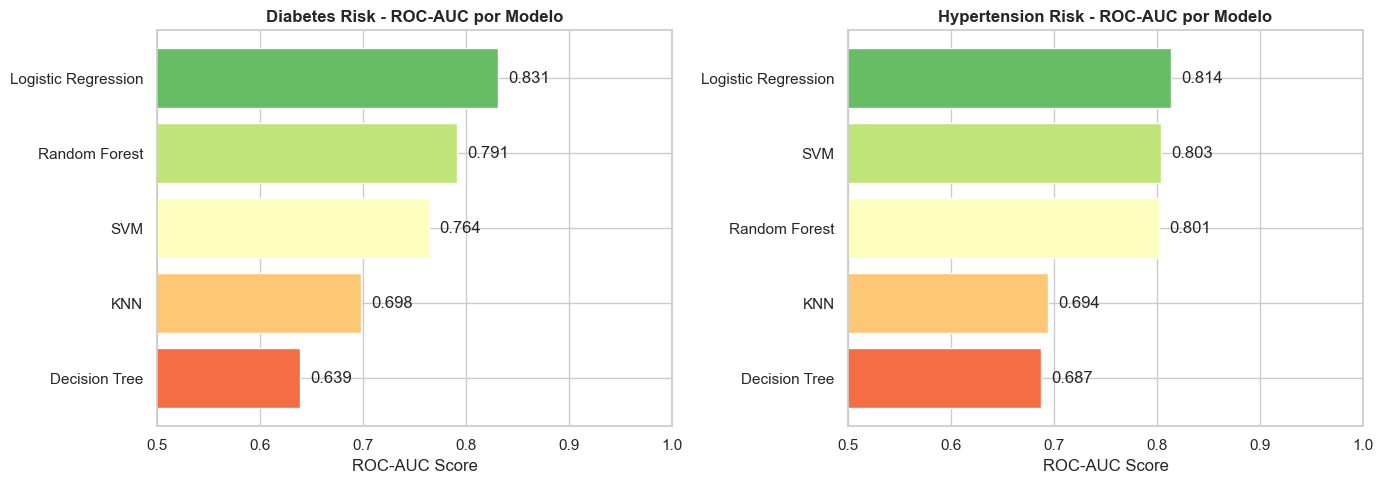

BEST MODELS SUMMARY
DIABETES - Best Model: Logistic Regression
           ROC-AUC: 0.8305
           F1-Score: 0.5619

HYPERTENSION - Best Model: Logistic Regression
               ROC-AUC: 0.8136
               F1-Score: 0.5540


In [71]:
diab_df = pd.DataFrame(diabetes_results)
hyp_df = pd.DataFrame(hypertension_results)

best_diab_model = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'Model']
best_diab_auc = diab_df['ROC-AUC'].max()
best_diab_f1 = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'F1-Score']

best_hyp_model = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'Model']
best_hyp_auc = hyp_df['ROC-AUC'].max()
best_hyp_f1 = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'F1-Score']

print("\n" + "="*60)
print("DIABETES RISK - Models Performance")
print("="*60)
print(diab_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("HYPERTENSION RISK - Models Performance")
print("="*60)
print(hyp_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes
ax = axes[0]
diab_sorted = diab_df.sort_values('ROC-AUC', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(diab_sorted)))
bars = ax.barh(diab_sorted['Model'], diab_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Diabetes Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, diab_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Hypertension
ax = axes[1]
hyp_sorted = hyp_df.sort_values('ROC-AUC', ascending=True)
bars = ax.barh(hyp_sorted['Model'], hyp_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Hypertension Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, hyp_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

print("BEST MODELS SUMMARY")
print("="*60)
print(f"DIABETES - Best Model: {best_diab_model}")
print(f"           ROC-AUC: {best_diab_auc:.4f}")
print(f"           F1-Score: {best_diab_f1:.4f}")
print(f"\nHYPERTENSION - Best Model: {best_hyp_model}")
print(f"               ROC-AUC: {best_hyp_auc:.4f}")
print(f"               F1-Score: {best_hyp_f1:.4f}")

### Export the data to the .pkl file

In [72]:
# Export the selected best models and scaler for the Streamlit app
os.makedirs("app/model", exist_ok=True)

bundle = {
    "scaler": scaler,
    "diabetes": diabetes_models[best_diab_model],
    "hypertension": hypertension_models[best_hyp_model],
    "diabetes_name": best_diab_model,
    "hypertension_name": best_hyp_model,
    "diabetes_metrics": {
        "auc": best_diab_auc,
        "f1": best_diab_f1,
        "recall": diab_df.loc[diab_df["Model"] == best_diab_model, "Recall"].values[0],
        "precision": diab_df.loc[diab_df["Model"] == best_diab_model, "Precision"].values[0],
    },
    "hypertension_metrics": {
        "auc": best_hyp_auc,
        "f1": best_hyp_f1,
        "recall": hyp_df.loc[hyp_df["Model"] == best_hyp_model, "Recall"].values[0],
        "precision": hyp_df.loc[hyp_df["Model"] == best_hyp_model, "Precision"].values[0],
    },
}

joblib.dump(bundle, "app/model/models.pkl")
print("Saved model")


Saved model


### 6) Cross-Validation

DIABETES RISK - Cross-validation scores:
--------------------------------------------------

Logistic Regression:
  ROC_AUC: 0.8258 (±0.0181)
  ACCURACY: 0.7486 (±0.0202)
  F1: 0.4658 (±0.0166)
  PRECISION: 0.3363 (±0.0200)
  RECALL: 0.7612 (±0.0248)

Decision Tree:
  ROC_AUC: 0.6810 (±0.0113)
  ACCURACY: 0.7746 (±0.0172)
  F1: 0.4082 (±0.0187)
  PRECISION: 0.3293 (±0.0253)
  RECALL: 0.5398 (±0.0217)

Random Forest:
  ROC_AUC: 0.8027 (±0.0242)
  ACCURACY: 0.8546 (±0.0114)
  F1: 0.3845 (±0.0566)
  PRECISION: 0.4917 (±0.0674)
  RECALL: 0.3182 (±0.0582)

SVM:
  ROC_AUC: 0.7755 (±0.0241)
  ACCURACY: 0.7782 (±0.0187)
  F1: 0.4224 (±0.0444)
  PRECISION: 0.3379 (±0.0380)
  RECALL: 0.5644 (±0.0591)

KNN:
  ROC_AUC: 0.7367 (±0.0143)
  ACCURACY: 0.6971 (±0.0180)
  F1: 0.3893 (±0.0132)
  PRECISION: 0.2745 (±0.0130)
  RECALL: 0.6717 (±0.0318)

--------------------------------------------------
HYPERTENSION RISK - Cross-validation scores:
--------------------------------------------------

Logistic

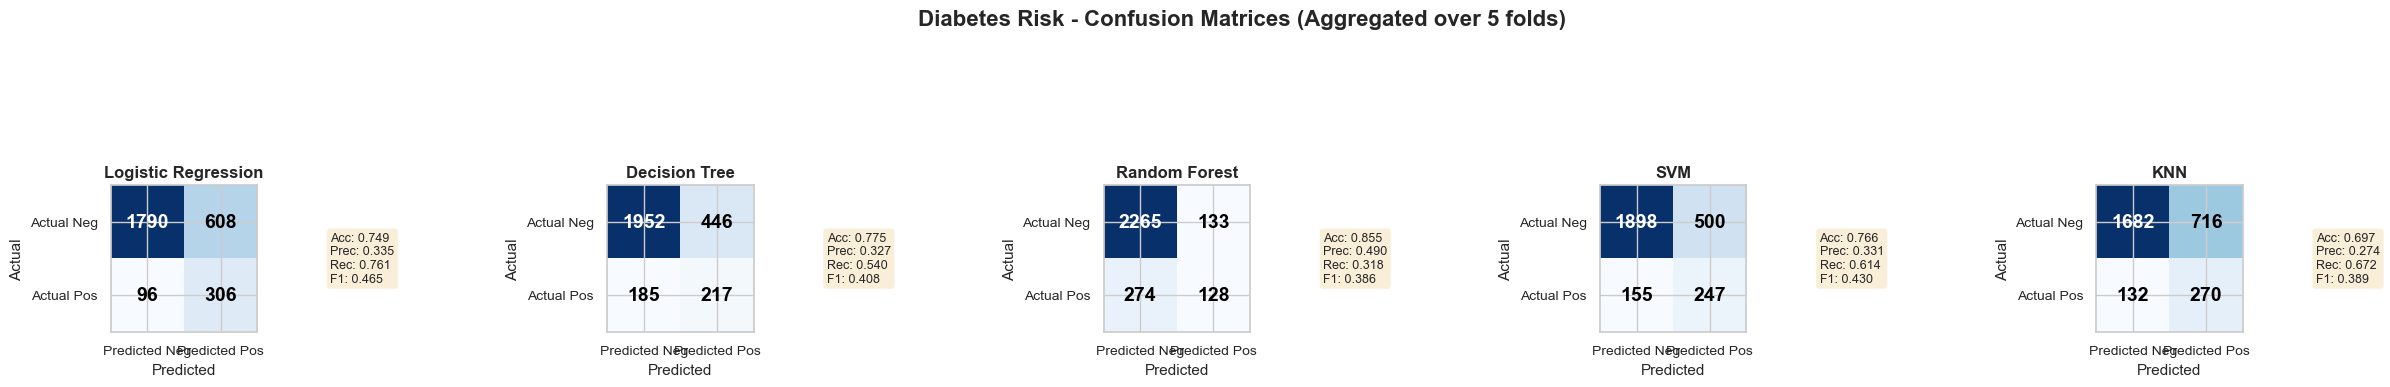

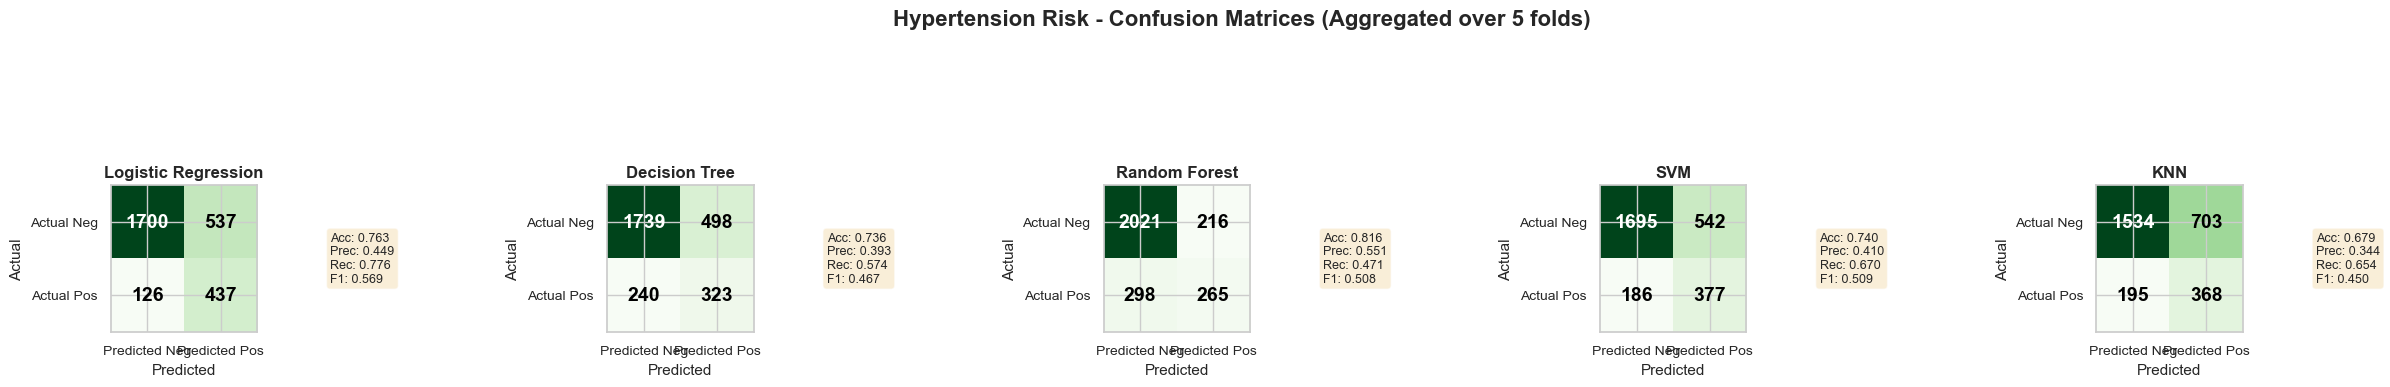


CROSS-VALIDATION SUMMARY (Mean ± Std)

DIABETES RISK:
                           roc_auc       accuracy             f1      precision         recall
Logistic Regression  0.826 ± 0.018  0.749 ± 0.020  0.466 ± 0.017  0.336 ± 0.020  0.761 ± 0.025
Decision Tree        0.681 ± 0.011  0.775 ± 0.017  0.408 ± 0.019  0.329 ± 0.025  0.540 ± 0.022
Random Forest        0.803 ± 0.024  0.855 ± 0.011  0.384 ± 0.057  0.492 ± 0.067  0.318 ± 0.058
SVM                  0.776 ± 0.024  0.778 ± 0.019  0.422 ± 0.044  0.338 ± 0.038  0.564 ± 0.059
KNN                  0.737 ± 0.014  0.697 ± 0.018  0.389 ± 0.013  0.274 ± 0.013  0.672 ± 0.032

HYPERTENSION RISK:
                           roc_auc       accuracy             f1      precision         recall
Logistic Regression  0.849 ± 0.013  0.763 ± 0.014  0.569 ± 0.017  0.449 ± 0.019  0.776 ± 0.029
Decision Tree        0.680 ± 0.032  0.736 ± 0.025  0.467 ± 0.037  0.395 ± 0.037  0.574 ± 0.046
Random Forest        0.822 ± 0.020  0.816 ± 0.012  0.507 ± 0.033  0.55

In [73]:
cv_results_diabetes = {}
cv_results_hypertension = {}

scoring_metrics = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=67)

print("DIABETES RISK - Cross-validation scores:")
print("-"*50)

for name, model_template in base_models.items():
    print(f"\n{name}:")
    cv_scores = {metric: [] for metric in scoring_metrics}
    
    # For each fold
    for train_idx, val_idx in skf.split(X_train_scaled, y_diab_train):
        # Split data
        X_fold_train = X_train_scaled.iloc[train_idx]
        X_fold_val = X_train_scaled.iloc[val_idx]
        y_fold_train = y_diab_train.iloc[train_idx]
        y_fold_val = y_diab_train.iloc[val_idx]
        
        # Apply SMOTE ONLY to training fold for SVM and KNN
        if name in ['SVM', 'KNN']:
            smote = SMOTE(random_state=67)
            X_fold_balanced, y_fold_balanced = smote.fit_resample(X_fold_train, y_fold_train)
            model = clone(model_template)
            model.fit(X_fold_balanced, y_fold_balanced)
        else:
            model = clone(model_template)
            model.fit(X_fold_train, y_fold_train)
        
        # Predict probabilities
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        
        # Calculate metrics
        cv_scores['roc_auc'].append(roc_auc_score(y_fold_val, y_proba))
        cv_scores['accuracy'].append(accuracy_score(y_fold_val, y_pred))
        cv_scores['f1'].append(f1_score(y_fold_val, y_pred))
        cv_scores['precision'].append(precision_score(y_fold_val, y_pred))
        cv_scores['recall'].append(recall_score(y_fold_val, y_pred))
    
    # Store results
    cv_results_diabetes[name] = cv_scores
    
    # Print summary for this model
    for metric in scoring_metrics:
        scores = np.array(cv_scores[metric])
        print(f"  {metric.upper()}: {scores.mean():.4f} (±{scores.std():.4f})")

print("\n" + "-"*50)
print("HYPERTENSION RISK - Cross-validation scores:")
print("-"*50)

for name, model_template in base_models.items():
    print(f"\n{name}:")
    cv_scores = {metric: [] for metric in scoring_metrics}
    
    for train_idx, val_idx in skf.split(X_train_scaled, y_hyp_train):
        X_fold_train = X_train_scaled.iloc[train_idx]
        X_fold_val = X_train_scaled.iloc[val_idx]
        y_fold_train = y_hyp_train.iloc[train_idx]
        y_fold_val = y_hyp_train.iloc[val_idx]
        
        if name in ['SVM', 'KNN']:
            smote = SMOTE(random_state=67)
            X_fold_balanced, y_fold_balanced = smote.fit_resample(X_fold_train, y_fold_train)
            model = clone(model_template)
            model.fit(X_fold_balanced, y_fold_balanced)
        else:
            model = clone(model_template)
            model.fit(X_fold_train, y_fold_train)
        
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        
        cv_scores['roc_auc'].append(roc_auc_score(y_fold_val, y_proba))
        cv_scores['accuracy'].append(accuracy_score(y_fold_val, y_pred))
        cv_scores['f1'].append(f1_score(y_fold_val, y_pred))
        cv_scores['precision'].append(precision_score(y_fold_val, y_pred))
        cv_scores['recall'].append(recall_score(y_fold_val, y_pred))
    
    cv_results_hypertension[name] = cv_scores
    
    for metric in scoring_metrics:
        scores = np.array(cv_scores[metric])
        print(f"  {metric.upper()}: {scores.mean():.4f} (±{scores.std():.4f})")

print("\n" + "="*60)
print("GENERATING CONFUSION MATRICES...")
print("="*60)

# Function to compute confusion matrix across all folds
def compute_aggregated_confusion_matrix(cv_results, X_data, y_data, model_templates, target_name):
    confusion_matrices = {}
    
    for name, model_template in model_templates.items():
        print(f"  Computing confusion matrix for {name}...")
        
        # Collect all predictions across folds
        all_y_true = []
        all_y_pred = []
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)
        
        for train_idx, val_idx in skf.split(X_data, y_data):
            X_fold_train = X_data.iloc[train_idx]
            X_fold_val = X_data.iloc[val_idx]
            y_fold_train = y_data.iloc[train_idx]
            y_fold_val = y_data.iloc[val_idx]
            
            if name in ['SVM', 'KNN']:
                smote = SMOTE(random_state=67)
                X_fold_balanced, y_fold_balanced = smote.fit_resample(X_fold_train, y_fold_train)
                model = clone(model_template)
                model.fit(X_fold_balanced, y_fold_balanced)
            else:
                model = clone(model_template)
                model.fit(X_fold_train, y_fold_train)
            
            y_pred = model.predict(X_fold_val)
            
            all_y_true.extend(y_fold_val)
            all_y_pred.extend(y_pred)
        
        # Compute confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred)
        confusion_matrices[name] = cm
    
    return confusion_matrices

# Compute confusion matrices for Diabetes
print("\n" + "-"*50)
print("Computing Confusion Matrices for DIABETES RISK:")
print("-"*50)
diab_confusion_matrices = compute_aggregated_confusion_matrix(
    cv_results_diabetes, X_train_scaled, y_diab_train, base_models, "Diabetes"
)

# Compute confusion matrices for Hypertension
print("\n" + "-"*50)
print("Computing Confusion Matrices for HYPERTENSION RISK:")
print("-"*50)
hyp_confusion_matrices = compute_aggregated_confusion_matrix(
    cv_results_hypertension, X_train_scaled, y_hyp_train, base_models, "Hypertension"
)

# Plot Confusion Matrices - Diabetes
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Diabetes Risk - Confusion Matrices (Aggregated over 5 folds)', fontsize=16, fontweight='bold')

for idx, (name, cm) in enumerate(diab_confusion_matrices.items()):
    ax = axes[idx]
    
    # Get values
    tn, fp, fn, tp = cm.ravel()
    
    # Create heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    
    # Add text annotations
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Neg', 'Predicted Pos'], fontsize=10)
    ax.set_yticklabels(['Actual Neg', 'Actual Pos'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    
    # Add metrics text below the matrix
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    ax.text(1.5, 0.5, metrics_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Plot Confusion Matrices - Hypertension
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Hypertension Risk - Confusion Matrices (Aggregated over 5 folds)', fontsize=16, fontweight='bold')

for idx, (name, cm) in enumerate(hyp_confusion_matrices.items()):
    ax = axes[idx]
    
    # Get values
    tn, fp, fn, tp = cm.ravel()
    
    # Create heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
    ax.set_title(name, fontsize=12, fontweight='bold')
    
    # Add text annotations
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Neg', 'Predicted Pos'], fontsize=10)
    ax.set_yticklabels(['Actual Neg', 'Actual Pos'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    
    # Add metrics text below the matrix
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    ax.text(1.5, 0.5, metrics_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY (Mean ± Std)")
print("="*60)

diab_summary = {}
hyp_summary = {}

for name in models.keys():
    diab_summary[name] = {metric: f"{np.mean(cv_results_diabetes[name][metric]):.3f} ± {np.std(cv_results_diabetes[name][metric]):.3f}" 
                          for metric in scoring_metrics}
    hyp_summary[name] = {metric: f"{np.mean(cv_results_hypertension[name][metric]):.3f} ± {np.std(cv_results_hypertension[name][metric]):.3f}" 
                          for metric in scoring_metrics}

diab_df_summary = pd.DataFrame(diab_summary).T
hyp_df_summary = pd.DataFrame(hyp_summary).T

print("\nDIABETES RISK:")
print(diab_df_summary.to_string())

print("\nHYPERTENSION RISK:")
print(hyp_df_summary.to_string())

diab_best_cv = max(cv_results_diabetes.keys(), 
                   key=lambda x: np.mean(cv_results_diabetes[x]['roc_auc']))
hyp_best_cv = max(cv_results_hypertension.keys(), 
                  key=lambda x: np.mean(cv_results_hypertension[x]['roc_auc']))

print(f"\nBEST MODEL (CV ROC-AUC):")
print(f"  Diabetes: {diab_best_cv} ({np.mean(cv_results_diabetes[diab_best_cv]['roc_auc']):.4f})")
print(f"  Hypertension: {hyp_best_cv} ({np.mean(cv_results_hypertension[hyp_best_cv]['roc_auc']):.4f})")


### ROC Curves

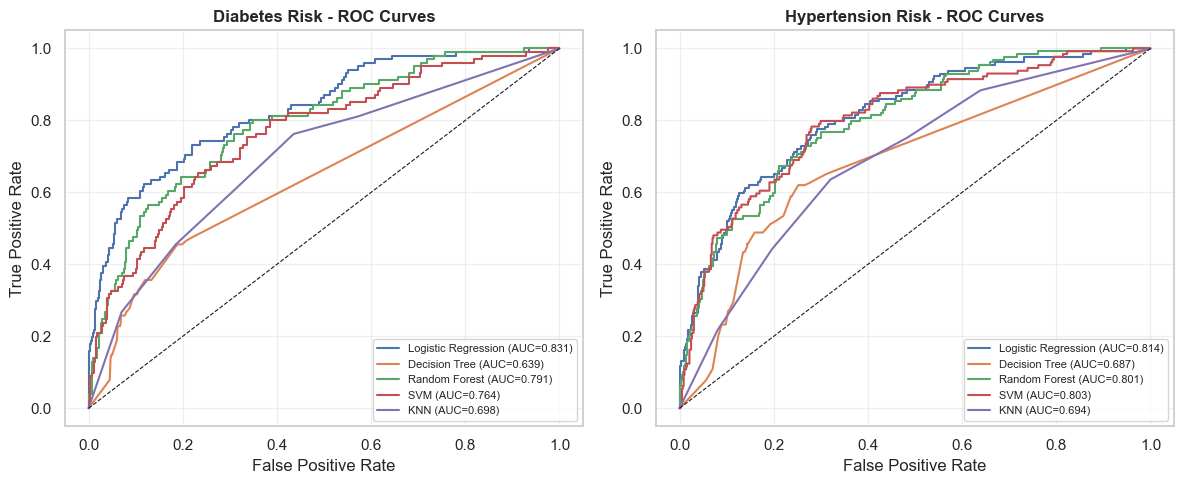

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diabetes ROC
for name, model in diabetes_models.items():
    if name in ['SVM', 'KNN']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_diab_test, y_proba)
    auc = roc_auc_score(y_diab_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Diabetes Risk - ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

# Hypertension ROC
for name, model in hypertension_models.items():
    if name in ['SVM', 'KNN']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_hyp_test, y_proba)
    auc = roc_auc_score(y_hyp_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Hypertension Risk - ROC Curves', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7) Feature Importance

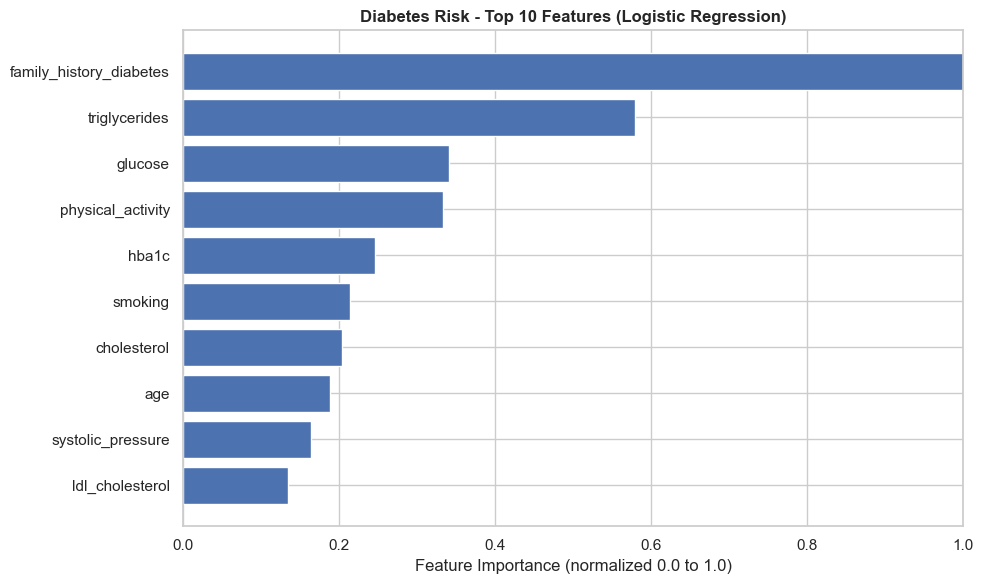

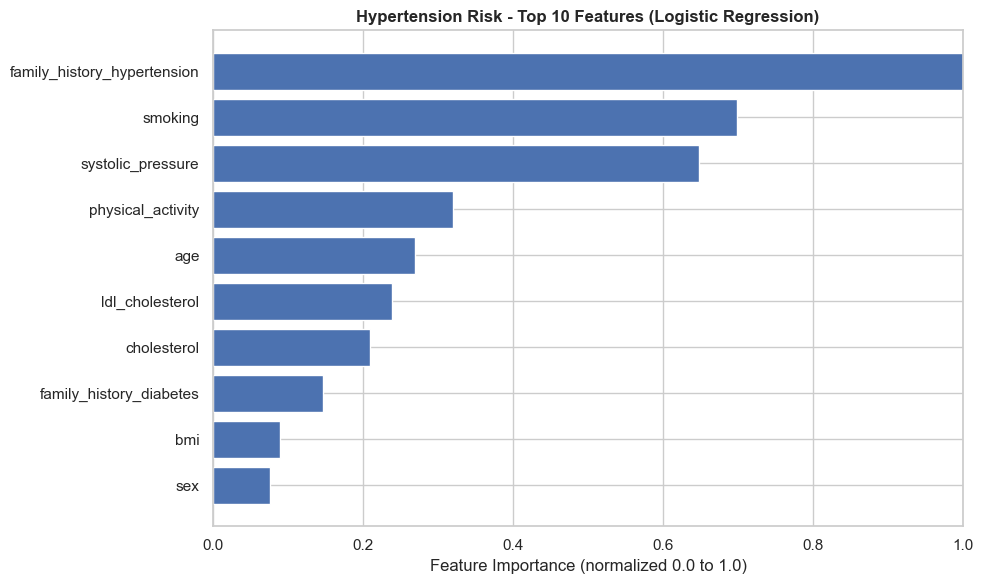

In [75]:
#DIABETES
if best_diab_model == 'Random Forest':
    model = diabetes_models['Random Forest']
    importances = model.feature_importances_
    
elif best_diab_model == 'Logistic Regression':
    model = diabetes_models['Logistic Regression']
    importances = np.abs(model.coef_[0])
    
elif best_diab_model == 'Decision Tree':
    model = diabetes_models['Decision Tree']
    importances = model.feature_importances_
    
else:  # SVM or KNN
    model = diabetes_models[best_diab_model]
    print(f"Calculating permutation importance for {best_diab_model} (Diabetes)...")
    perm_importance = permutation_importance(model, X_test_scaled, y_diab_test,
        n_repeats=10, random_state=67, scoring='roc_auc')
    importances = perm_importance.importances_mean

# Normalize
importances = importances / importances.max()
feature_names = all_features
indices = np.argsort(importances)[::-1]

# Plot Diabetes
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices[:10]])
plt.yticks(range(10), [feature_names[i] for i in indices[:10]])
plt.xlabel('Feature Importance (normalized 0.0 to 1.0)', fontsize=12)
plt.title(f'Diabetes Risk - Top 10 Features ({best_diab_model})', fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()



# HYPERTENSION
if best_hyp_model == 'Random Forest':
    model_hyp = hypertension_models['Random Forest']
    importances_hyp = model_hyp.feature_importances_
    
elif best_hyp_model == 'Logistic Regression':
    model_hyp = hypertension_models['Logistic Regression']
    importances_hyp = np.abs(model_hyp.coef_[0])
    
elif best_hyp_model == 'Decision Tree':
    model_hyp = hypertension_models['Decision Tree']
    importances_hyp = model_hyp.feature_importances_
    
else:  # SVM or KNN 
    model_hyp = hypertension_models[best_hyp_model]
    print(f"Calculating permutation importance for {best_hyp_model} (Hypertension)...")
    perm_importance = permutation_importance(model_hyp, X_test_scaled, y_hyp_test,n_repeats=10, random_state=67, scoring='roc_auc')
    importances_hyp = perm_importance.importances_mean  

# Normalize
importances_hyp = importances_hyp / importances_hyp.max()
indices_hyp = np.argsort(importances_hyp)[::-1]

# Plot Hypertension
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances_hyp[indices_hyp[:10]])
plt.yticks(range(10), [feature_names[i] for i in indices_hyp[:10]])
plt.xlabel('Feature Importance (normalized 0.0 to 1.0)', fontsize=12)
plt.title(f'Hypertension Risk - Top 10 Features ({best_hyp_model})', fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()
